# §4 Individual with ML#2 filter (v12)

Per-combo metrics and equity/drawdown curves after applying the V3
booster + pooled-R:R isotonic calibrator filter.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 4,537
Loaded combos_ml2 from cache (10 combos).


ML2 portfolio trade counts: {'fixed_dollars_500': 0, 'pct5_compound': 0}


In [2]:
rows = []
for cid, entry in s4_pnl_by_combo.items():
    pnl_base = entry['pnl_base']; risk_base = entry['risk_base']
    if len(pnl_base) == 0:
        for policy in POLICIES:
            rows.append({'combo_id': cid, 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = entry['by_policy'][policy]
        rows.append({'combo_id': cid, 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf4 = pd.DataFrame(rows)
perf4

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v11_2646,fixed_dollars_500,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,v11_2646,pct5_compound,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,v11_391,fixed_dollars_500,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,v11_391,pct5_compound,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,v11_28651,fixed_dollars_500,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,v11_28651,pct5_compound,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,v11_17782,fixed_dollars_500,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,v11_17782,pct5_compound,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,v11_263,fixed_dollars_500,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,v11_263,pct5_compound,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/root/intra/scripts/evaluation/_top_perf_common.py:510: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="upper left", ncol=2)


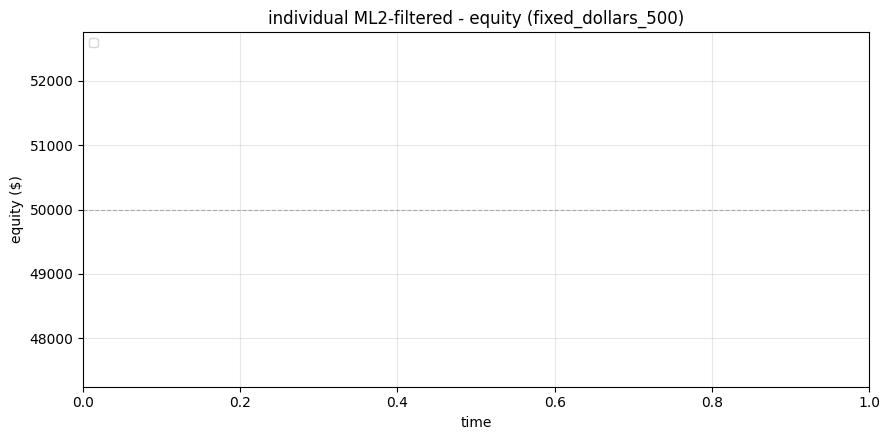

In [3]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'fixed_dollars_500')

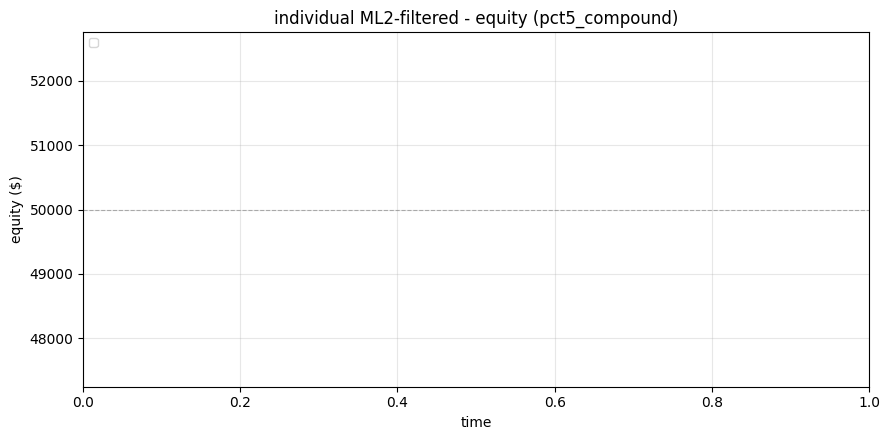

In [4]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'pct5_compound')

/root/intra/scripts/evaluation/_top_perf_common.py:529: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc="lower left", ncol=2)


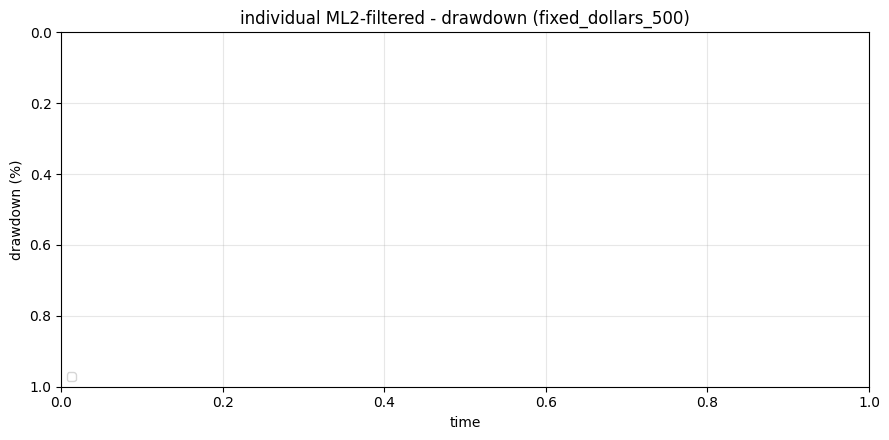

In [5]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'fixed_dollars_500')

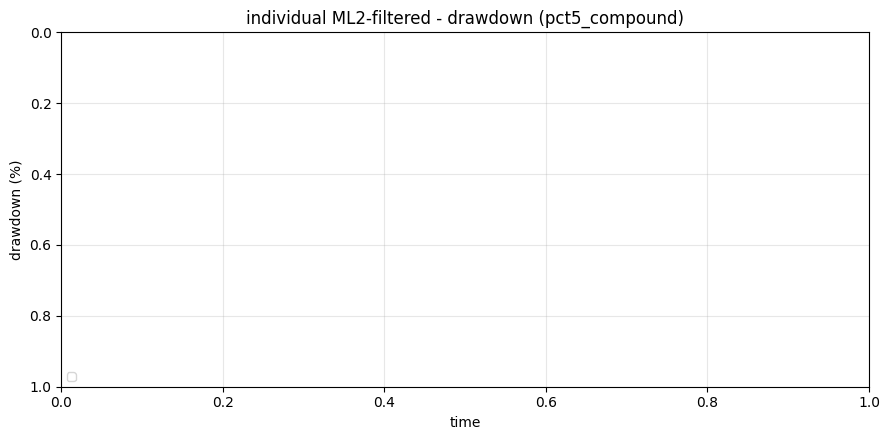

In [6]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'pct5_compound')